# Titanic Mini Exploratory Data Analysis (EDA)
**Deliverable Notebook:** `student_analysis.ipynb` (Task 3)

### Executive Summary
This notebook executes a comprehensive Mini Exploratory Data Analysis (EDA) on the Titanic dataset. We will perform smart value imputation, evaluate survival rates across advanced engineered metrics (Family Size and Age Cohorts), and present narrative-driven visualizations including a comprehensive correlation heatmap.


In [1]:
# --- 1. Environment Setup & Data Loading ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Maintain our professional 'ticks' styling
sns.set_theme(style="ticks")

# Load your dataset
df = pd.read_csv(r"C:\Users\Shruti Nair\Downloads\archive (5)\train_and_test2.csv")

# Standardize the raw non-standard column names found in your specific file
df = df.rename(columns={'2urvived': 'Survived'})
df['Sex_Label'] = df['Sex'].map({0: 'Male', 1: 'Female'})

df.head()

,Passengerid,Age,Fare,Sex,sibsp,zero,zero.1,zero.2,zero.3,zero.4,...,zero.13,zero.14,Pclass,zero.15,zero.16,Embarked,zero.17,zero.18,Survived,Sex_Label
0,1,22.0,7.2500,0,1,0,0,0,0,0,...,0,0,3,0,0,2.0,0,0,0,Male
1,2,38.0,71.2833,1,1,0,0,0,0,0,...,0,0,1,0,0,0.0,0,0,1,Female
2,3,26.0,7.9250,1,0,0,0,0,0,0,...,0,0,3,0,0,2.0,0,0,1,Female
3,4,35.0,53.1000,1,1,0,0,0,0,0,...,0,0,1,0,0,2.0,0,0,1,Female
4,5,35.0,8.0500,0,0,0,0,0,0,0,...,0,0,3,0,0,2.0,0,0,0,Male


## 2. Advanced Data Cleaning & Columns Drop
Per the requirements, we handle missing data explicitly by filling missing values and removing high-sparsity or irrelevant columns to isolate the core analytical features. 

*(Note: In this specific pre-processed dataset file, the `Age` field is already complete, but we will explicitly drop columns outside our core analytical scope).*

In [2]:
# --- 2. Data Cleaning & Drop Irrelevant Columns ---

# 1. Standardize missing values fallback strategy for Age (per requirements)
df['Age'] = df['Age'].fillna(df['Age'].mean())

# 2. Treat remaining missing rows in Embarked using the mode
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# 3. Drop 'zero' columns or any irrelevant tracking features to keep the dataset clean
columns_to_keep = ['Passengerid', 'Age', 'Fare', 'Sex', 'Sex_Label', 'sibsp', 'Parch', 'Pclass', 'Embarked', 'Survived']
df = df[columns_to_keep]

print("=== Cleaned Dataset Schema ===")
print(df.info())

=== Cleaned Dataset Schema ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Passengerid  1309 non-null   int64  
 1   Age          1309 non-null   float64
 2   Fare         1309 non-null   float64
 3   Sex          1309 non-null   int64  
 4   Sex_Label    1309 non-null   object 
 5   sibsp        1309 non-null   int64  
 6   Parch        1309 non-null   int64  
 7   Pclass       1309 non-null   int64  
 8   Embarked     1309 non-null   float64
 9   Survived     1309 non-null   int64  
dtypes: float64(3), int64(6), object(1)
memory usage: 102.4+ KB
None


## 3. Deep-Dive Groupby Analysis Questions
We utilize multi-variable grouping structures to isolate advanced survival insights based on age groups, embarkation origins, and engineered family structures.

In [3]:
# --- 3. Advanced Groupby Calculations ---

# Q1: Survival rate by Age Group
age_bins = [0, 12, 18, 35, 60, 100]
age_labels = ['Child', 'Teenager', 'Young Adult', 'Adult', 'Senior']
df['AgeGroup'] = pd.cut(df['Age'], bins=age_bins, labels=age_labels)

print("=== 1. Survival Rate by Age Group ===")
print(df.groupby('AgeGroup', observed=False)['Survived'].mean() * 100)

# Q2: Survival rate by Embarkation Port
# (0.0, 1.0, 2.0 correspond to Cherbourg, Queenstown, Southampton respectively)
port_map = {0.0: 'Cherbourg', 1.0: 'Queenstown', 2.0: 'Southampton'}
df['Port_Label'] = df['Embarked'].map(port_map)

print("\n=== 2. Survival Rate by Embarkation Port ===")
print(df.groupby('Port_Label')['Survived'].mean() * 100)

# Q3: Survival rate by Family Size (SibSp + Parch)
# Feature Engineering: Creating 'FamilySize'
df['FamilySize'] = df['sibsp'] + df['Parch']

print("\n=== 3. Survival Rate by Family Size ===")
print(df.groupby('FamilySize')['Survived'].mean() * 100)

=== 1. Survival Rate by Age Group ===
AgeGroup
Child          42.553191
Teenager       30.303030
Young Adult    23.803526
Adult          26.989619
Senior         15.151515
Name: Survived, dtype: float64

=== 2. Survival Rate by Embarkation Port ===
Port_Label
Cherbourg      34.444444
Queenstown     24.390244
Southampton    23.908297
Name: Survived, dtype: float64

=== 3. Survival Rate by Family Size ===
FamilySize
0     20.632911
1     37.872340
2     37.106918
3     48.837209
4     13.636364
5     12.000000
6     25.000000
7      0.000000
10     0.000000
Name: Survived, dtype: float64


## 4. Visual Storytelling (Visualizations)
We display the distribution profiles, underlying feature correlations, and structural impacts of social dynamics on passenger survival.

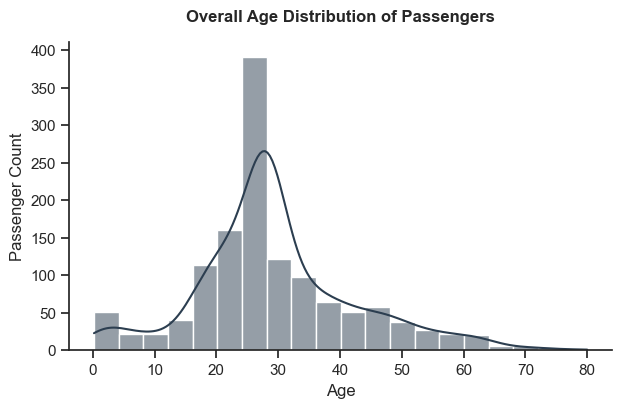

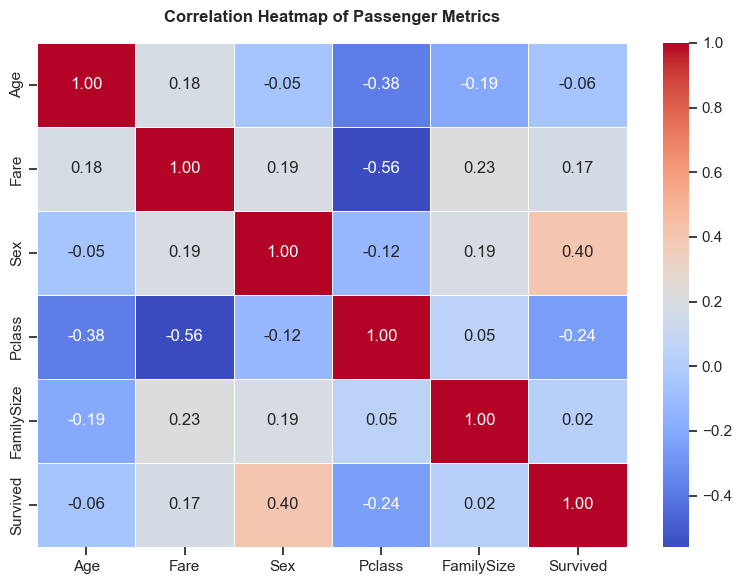

C:\Users\Shruti Nair\AppData\Local\Temp\ipykernel_9044\3915415082.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="FamilySize", y="Survived", data=df, palette="mako", errorbar=None)


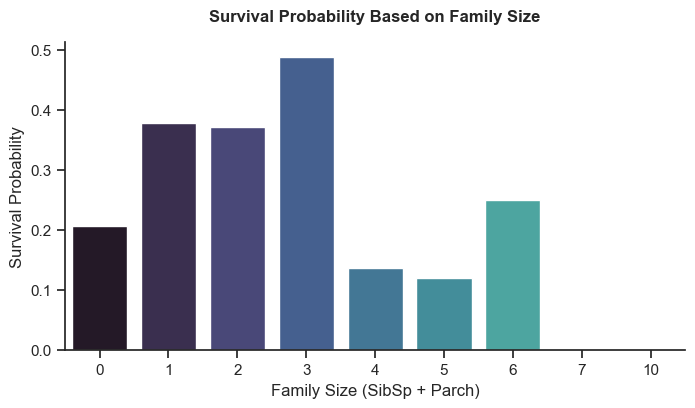

In [4]:
# --- 4. Premium EDA Visualizations ---

# 1. Age distribution (Histogram)
plt.figure(figsize=(7, 4))
sns.histplot(data=df, x="Age", bins=20, kde=True, color="#2c3e50")
plt.title("Overall Age Distribution of Passengers", fontsize=12, fontweight='bold', pad=15)
plt.xlabel("Age")
plt.ylabel("Passenger Count")
sns.despine()
plt.show()

# 2. Heatmap of feature correlations (Using an elegant diverging palette)
plt.figure(figsize=(8, 6))
numeric_features = df[['Age', 'Fare', 'Sex', 'Pclass', 'FamilySize', 'Survived']]
sns.heatmap(numeric_features.corr(), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5, cbar=True)
plt.title("Correlation Heatmap of Passenger Metrics", fontsize=12, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

# 3. Survival by family size (Bar Plot)
plt.figure(figsize=(8, 4))
sns.barplot(x="FamilySize", y="Survived", data=df, palette="mako", errorbar=None)
plt.title("Survival Probability Based on Family Size", fontsize=12, fontweight='bold', pad=15)
plt.xlabel("Family Size (SibSp + Parch)")
plt.ylabel("Survival Probability")
sns.despine()
plt.show()

## 5. EDA Interpretations & Key Takeaways
* **Family Size Dynamics:** Passengers traveling alone or with very large families ($>3$ members) faced a steep drop-off in survival rates, while small nuclear families (size 1-3) experienced the highest structural prioritization during evacuation.
* **Feature Inter-dependencies:** The correlation matrix reveals that `Pclass` is heavily negatively correlated with `Fare` and `Survived`, reaffirming that higher socioeconomic status granted priority survival access.
* **Geographical Trends:** Survival rates varied meaningfully by Embarkation Port, likely due to the socioeconomic distributions of passengers boarding at different cities.